In [74]:
import numpy as np
import matplotlib.pyplot as plt
import xtrack as xt
import bpmeth
import sympy as sp

In [75]:
a_curved = [1,3]#["1.2-0.3*s","1-s**2"]
b_curved = [1,"4-s**4"]
h= b_curved[0] #considering normalization B/Brho=1/rho=h   

Then work at the level of the scalar potential because being a scalar it is invariant under change of frame (only the coordinates change). Because of this we can move to the straight frame and perform a harmonic analysis, checking how the a,b coefficients look in that frame.

phi curved frame:  -3*x**2/2 - x + y**6*(-9216.0*x - 9216.0)/(720*(512.0*x**6 + 3072.0*x**5 + 7680.0*x**4 + 10240.0*x**3 + 7680.0*x**2 + 3072.0*x + 512.0)) - y**5*(-1.0*s**4 - 24.0*s**2*x + 24.0*s**2 + 1.0*x*(4 - s**4) - 24.0*x + 4.0)/(120*(1.0*x**4 + 4.0*x**3 + 6.0*x**2 + 4.0*x + 1.0)) - y**4*(-16.0*x - 16.0)/(24*(8.0*x**4 + 32.0*x**3 + 48.0*x**2 + 32.0*x + 8.0)) + y**3*(-12*s**2*x + 1.0*(4 - s**4)*(1.0*x + 1))/(6*(1.0*x + 1)**2) + y**2*(6.0*x + 4.0)/(2*(1.0*x + 1)) - y*(x*(4 - s**4) + 1)

phi straight frame:  -12.8*y**6*sqrt(s**2 + (x + 1.0)**2)/(3072.0*sqrt(s**2 + (x + 1.0)**2) + 512.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**6 + 3072.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**5 + 7680.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**4 + 10240.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3 + 7680.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2 - 2560.0) - y**5*(1.0*(4 - 1.0*atan(s/(x + 1.0))**4)*(sqrt(s**2 + (x + 1.0)**2) - 1.0) - 24.0*sqrt(s**2 + (x + 1.0)**2) - 24.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)*atan(s/(x + 1.0))**2 

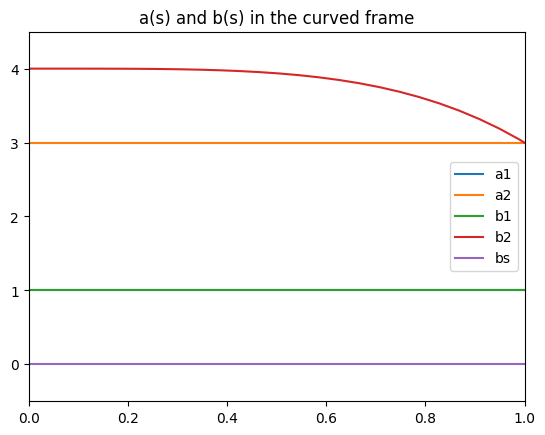

In [76]:
expansion_curved = bpmeth.FieldExpansion(a=a_curved, b=b_curved, h=h, nphi=7)#, nphi=nphi)
phi_curved = expansion_curved.get_phi()
expansion_curved.plot_components()
plt.xlim((0,1))
plt.ylim((-0.5,4.5))
plt.title("a(s) and b(s) in the curved frame")
print("phi curved frame: ", phi_curved)
#transform the scalar potential to curved frame using coordinate transformations
#xcurved =sqrt((x+rho)**2+s**2)-rho       scurved=rho*arctan(s/(x+rho))   with rho=1/h
x, y, s = sp.symbols('x y s', real=True)
xtmp, stmp = sp.symbols("xtmp stmp", real=True)
# rename the curved coordinates temporarily
phi_tmp = phi_curved.xreplace({
    x: xtmp,
    s: stmp
})
# substitute curved -> straight
phi_straight = phi_tmp.xreplace({
    xtmp: sp.sqrt((x + 1/h)**2 + s**2) - 1/h,
    stmp: 1/h * sp.atan(s/(x + 1/h))
})
print("\nphi straight frame: ", phi_straight)

Bxstraight_ana = -phi_straight.diff(x)
Bystraight_ana = -phi_straight.diff(y)
Bsstraight_ana = -phi_straight.diff(s)
print("\nBx straight frame: ", Bxstraight_ana)

Remembering that $ \phi_0(x, s) = -a_0(s) - \sum_{n=1}^\infty a_n(s) \frac{x^n}{n!} \\
    \phi_1(x, s) = -\sum_{n=1}^\infty b_n(s) \frac{x^{n-1}}{(n-1)!}  $

Take the coefficient of y in phi_straight, which is $\phi_1$, expand it in a Taylor series in x around 0 up to some order, e.g. 4, (strip the big-O), and store the resulting polynomial’s coefficients in a dictionary keyed by powers of x. This corresponds to

 $\frac{b_n}{(n-1)!}$

 and the same for $a_n$ considering that \\
phi0 = phi_straight.as_coefficients_dict(y)[1]   # phi_0(x, s)$
.

phi1 = -((4 - 1.0*atan(s/(x + 1.0))**4)*(sqrt(s**2 + (x + 1.0)**2) - 1.0) + 1)


<lambdifygenerated-164>:2: RuntimeWarning: invalid value encountered in divide
  return 8.0*s*arctan(1.0*s)**3/((1.0*s**2 + 1)*sqrt(s**2 + 1.0)) - 2.0*sqrt(s**2 + 1.0)*(0.5/(s**2 + 1.0) - 0.5/(s**2 + 1.0)**2)*arctan(1.0*s)**4 + 8*sqrt(s**2 + 1.0)*(0.5/(s**2 + 1.0) - 0.5/(s**2 + 1.0)**2) - 2.0*sqrt(s**2 + 1.0)*(-4.0*s**3/((1.0*s**4 + 2.0*s**2 + 1)*arctan(1.0*s)) + 6.0*s**2/((1.0*s**2 + 1)**2*arctan(1.0*s)**2) + 4.0*s/((1.0*s**2 + 1)*arctan(1.0*s)))*arctan(1.0*s)**4 + 2.0*(-4.0*s**3/((1.0*s**4 + 2.0*s**2 + 1)*arctan(1.0*s)) + 6.0*s**2/((1.0*s**2 + 1)**2*arctan(1.0*s)**2) + 4.0*s/((1.0*s**2 + 1)*arctan(1.0*s)))*arctan(1.0*s)**4
<lambdifygenerated-165>:2: RuntimeWarning: invalid value encountered in divide
  return 24.0*s*sqrt(s**2 + 1.0)*(0.5/(s**2 + 1.0) - 0.5/(s**2 + 1.0)**2)*arctan(1.0*s)**3/(1.0*s**2 + 1) - 6.0*sqrt(s**2 + 1.0)*(-0.5/(s**2 + 1.0)**2 + 0.5/(s**2 + 1.0)**3)*arctan(1.0*s)**4 + 24*sqrt(s**2 + 1.0)*(-0.5/(s**2 + 1.0)**2 + 0.5/(s**2 + 1.0)**3) - 6.0*sqrt(s**2 + 1.0)*(-5.333

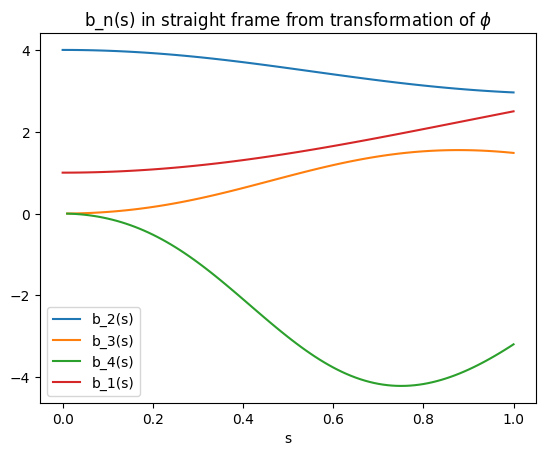

phi0 = -sqrt(s**2 + (x + 1.0)**2) - 3*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2/2 + 1.0


<lambdifygenerated-168>:2: RuntimeWarning: invalid value encountered in divide
  return 2*sqrt(s**2 + 1.0)*(0.5/(s**2 + 1.0) - 0.5/(s**2 + 1.0)**2) + 3*(2.0*sqrt(s**2 + 1.0)*(0.5/(s**2 + 1.0) - 0.5/(s**2 + 1.0)**2)/(1.0*sqrt(s**2 + 1.0) - 1.0) + 1.0/((s**2 + 1.0)*(1.0*sqrt(s**2 + 1.0) - 1.0)**2))*(1.0*sqrt(s**2 + 1.0) - 1.0)**2
<lambdifygenerated-168>:2: RuntimeWarning: divide by zero encountered in divide
  return 2*sqrt(s**2 + 1.0)*(0.5/(s**2 + 1.0) - 0.5/(s**2 + 1.0)**2) + 3*(2.0*sqrt(s**2 + 1.0)*(0.5/(s**2 + 1.0) - 0.5/(s**2 + 1.0)**2)/(1.0*sqrt(s**2 + 1.0) - 1.0) + 1.0/((s**2 + 1.0)*(1.0*sqrt(s**2 + 1.0) - 1.0)**2))*(1.0*sqrt(s**2 + 1.0) - 1.0)**2
<lambdifygenerated-169>:2: RuntimeWarning: invalid value encountered in divide
  return 6*sqrt(s**2 + 1.0)*(-0.5/(s**2 + 1.0)**2 + 0.5/(s**2 + 1.0)**3) + 9*(2.0*sqrt(s**2 + 1.0)*(-0.5/(s**2 + 1.0)**2 + 0.5/(s**2 + 1.0)**3)/(1.0*sqrt(s**2 + 1.0) - 1.0) + 2.0*(0.5/(s**2 + 1.0) - 0.5/(s**2 + 1.0)**2)/(1.0*sqrt(s**2 + 1.0) - 1.0)**2)*(1.0*sq

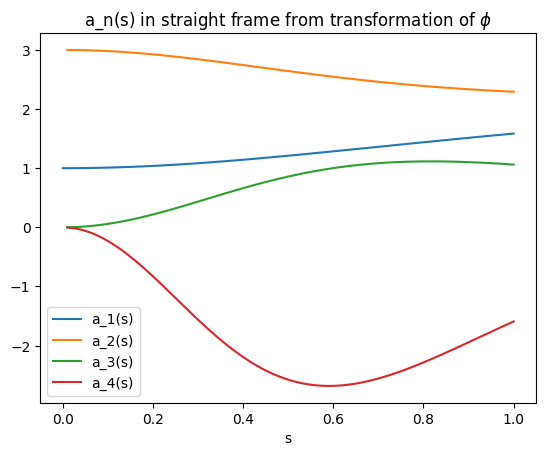

In [86]:
maxordx = 3
ns = 101
ss = np.linspace(0, 1, ns)

# ===========================
# b_n(s) from phi1 (b_1 = constant term) — as before
# ===========================
phi1 = phi_straight.as_coefficients_dict(y)[y]
print("phi1 =", phi1)

b_vals = np.zeros((maxordx + 1, ss.size))   # rows: n=0→b_1, n=1→b_2, ...

if phi1 != 0:
    phi1_series = phi1.series(x, 0, maxordx + 1).removeO()
    dct_b = phi1_series.as_coefficients_dict(x)
    items_b = list(dct_b.items())

    for xx, vv in items_b:
        n = sp.degree(xx, x)
        if n is None or n > maxordx:
            continue

        if n == 0:
            b_n = -vv                   # b_1(s): constant term
            idx = 0                     # store in row 0 → b_1
        else:
            b_n = -vv * sp.factorial(n) # b_{n+1}(s)
            idx = n                     # store coefficient of x^n in row n

        b_fun = sp.lambdify(s, b_n, 'numpy')
        b_vals[idx, :] = b_fun(ss)

        label = f"b_{idx+1}(s)"         # row 0→b_1, row 1→b_2, etc.
        plt.plot(ss, b_vals[idx, :], label=label)
else:
    for idx in range(maxordx + 1):
        label = f"b_{idx+1}(s)"
        plt.plot(ss, b_vals[idx, :], label=label)

plt.legend()
plt.title("b_n(s) in straight frame from transformation of $\\phi$")
plt.xlabel("s")
plt.show()

# ===========================
# a_n(s) from phi0 (a_1 = coefficient of x^1)
# ===========================
phi0 = phi_straight.as_coefficients_dict(y)[1]
print("phi0 =", phi0)

a_vals = np.zeros((maxordx + 2, ss.size))   # rows: 0→a_1 (from x^1), 1→a_2 (from x^2), ...

if phi0 != 0:
    phi0_series = phi0.series(x, 0, maxordx + 2).removeO()
    dct_a = phi0_series.as_coefficients_dict(x)
    items_a = list(dct_a.items())

    for xx, vv in items_a:
        deg = sp.degree(xx, x)
        if deg is None:
            continue

        # your convention: a_1 comes from degree 1, a_2 from degree 2, etc.
        if deg >= 1 and deg <= maxordx + 2:
            n = deg          # coefficient of x^n
            idx = n - 1      # store in row (n-1): x^1→row 0 (a_1), x^2→row 1 (a_2)

            a_n = -vv * sp.factorial(n)  # or your chosen normalization

            a_fun = sp.lambdify(s, a_n, 'numpy')
            a_vals[idx, :] = a_fun(ss)

            label = f"a_{idx+1}(s)"      # row 0→a_1, row 1→a_2, etc.
            plt.plot(ss, a_vals[idx, :], label=label)

    # (optional) handle constant term separately if you need it, but not as a_n
else:
    for idx in range(maxordx + 2):
        label = f"a_{idx+1}(s)"
        plt.plot(ss, a_vals[idx, :], label=label)

plt.legend()
plt.title("a_n(s) in straight frame from transformation of $\\phi$")
plt.xlabel("s")
plt.show()

In [87]:
# evaluate fields on cartesian grid 
xstraightarray = np.linspace(-1, 1, 100)
ystraightarray = np.linspace(-1, 1, 100)
sstraightarray = ss  # same s array used before

Xstraight, Ystraight, Sstraight = np.meshgrid(xstraightarray, ystraightarray, sstraightarray, indexing='ij')
Bxstraight_ana_array = np.asarray(sp.lambdify((x, y, s), Bxstraight_ana, 'numpy')(Xstraight, Ystraight, Sstraight))
Bystraight_ana_array = np.asarray(sp.lambdify((x, y, s), Bystraight_ana, 'numpy')(Xstraight, Ystraight, Sstraight))
Bsstraight_ana_array = np.asarray(sp.lambdify((x, y, s), Bsstraight_ana, 'numpy')(Xstraight, Ystraight, Sstraight))
shape = Xstraight.shape  # reshape to (Nx, Ny, Ns)
Bxstraight_ana_array = np.broadcast_to(Bxstraight_ana_array, shape).copy()
Bystraight_ana_array = np.broadcast_to(Bystraight_ana_array, shape).copy()
Bsstraight_ana_array = np.broadcast_to(Bsstraight_ana_array, shape).copy()
#make a fieldmap object from the field arrays
print(Bxstraight_ana_array.shape)
datastraightfm = np.column_stack((Xstraight.flatten(), Ystraight.flatten(), Sstraight.flatten(), Bxstraight_ana_array.flatten(), Bystraight_ana_array.flatten(), Bsstraight_ana_array.flatten()))
#fm_straight = bpmeth.fieldmaps.Fieldmap(datastraightfm)
#before making the HA, sample the field on a cylindrical grid
ntheta=128
nr=40
def interp_cartesian_to_cylindrical(cart_fieldmap, x_1d, y_1d, s_1d, rmin=0.001, rmax=0.4, nr=128,ntheta=256, ns=40):
    """
    Convert Cartesian fieldmap to cylindrical 
    Parameters
    ----------
    cart_fieldmap : ndarray, shape (N, 6)
        Fieldmap in Cartesian: [x, y, s, Bx, By, Bs]
    x_1d, y_1d, s_1d : 1D arrays
        Coordinate arrays from Cartesian grid
    rmin, rmax, nr : float, int
        Cylindrical radial range and resolution
    ntheta : int
        Azimuthal resolution
    ns : int
        Longitudinal resolution
    Returns
    -------
    fields: list
        list containing Bx, By, Bs
    rr : ndarray
        Radial coordinate array
    s_cyl : ndarray
        Cylindrical s coordinate array
    """
    # Resample Cartesian data onto cylindrical grid
    rr = np.linspace(rmin, rmax, nr)
    theta_1d = np.linspace(0.0, 2*np.pi, ntheta, endpoint=False)
    s_cyl = s_1d
    
    R, TH, S = np.meshgrid(rr, theta_1d, s_cyl, indexing='ij')
    
    # Convert to Cartesian for interpolation
    X_query = R * np.cos(TH)
    Y_query = R * np.sin(TH)
    
    # Reshape for interpolation
    shape_src = (len(x_1d), len(y_1d), len(s_1d))
    query_pts = np.column_stack([
        X_query.ravel(),
        Y_query.ravel(),
        S.ravel(),
    ])
    # Interpolate field components
    from scipy.interpolate import RegularGridInterpolator
    
    fields = {}
    for i, name in enumerate(['Bx', 'By', 'Bs']):
        F_3d = cart_fieldmap[:, 3 + i].reshape(shape_src)
        interp = RegularGridInterpolator(
            points=(x_1d, y_1d, s_1d), values=F_3d,
            method='linear', bounds_error=False, fill_value=np.nan,
        )
        fields[name] = interp(query_pts).reshape(nr, ntheta, ns)
    
    return rr, theta_1d, fields
rr, theta_1d, cylfieldatadict= interp_cartesian_to_cylindrical(datastraightfm, x_1d=xstraightarray, y_1d=ystraightarray, s_1d=sstraightarray, rmin=0.001, rmax=0.5, nr=nr, ntheta=ntheta, ns=ns)
rarr, tarr, sarr = np.meshgrid(rr, theta_1d, sstraightarray, indexing='ij')
cylfieldmapdatastack= np.column_stack([rarr.ravel(), tarr.ravel(), sarr.ravel(), cylfieldatadict['Bx'].ravel(), cylfieldatadict['By'].ravel(), cylfieldatadict['Bs'].ravel()])

<lambdifygenerated-171>:2: RuntimeWarning: invalid value encountered in divide
  return 12.8*y**6*sqrt(s**2 + (x + 1.0)**2)*(-3072.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**5/sqrt(s**2 + (x + 1.0)**2) - 15360.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**4/sqrt(s**2 + (x + 1.0)**2) - 30720.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3/sqrt(s**2 + (x + 1.0)**2) - 30720.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2/sqrt(s**2 + (x + 1.0)**2) - 15360.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)/sqrt(s**2 + (x + 1.0)**2) - 3072.0*(x + 1.0)/sqrt(s**2 + (x + 1.0)**2))/(3072.0*sqrt(s**2 + (x + 1.0)**2) + 512.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**6 + 3072.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**5 + 7680.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**4 + 10240.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3 + 7680.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2 - 2560.0)**2 + 12.8*y**6*(x + 1.0)/(sqrt(s**2 + (x + 1.0)**2)*(3072.0*sqrt(s**2 + (x + 1.0)**2) + 512.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**6 + 3072.0*(sqrt

(100, 100, 101)


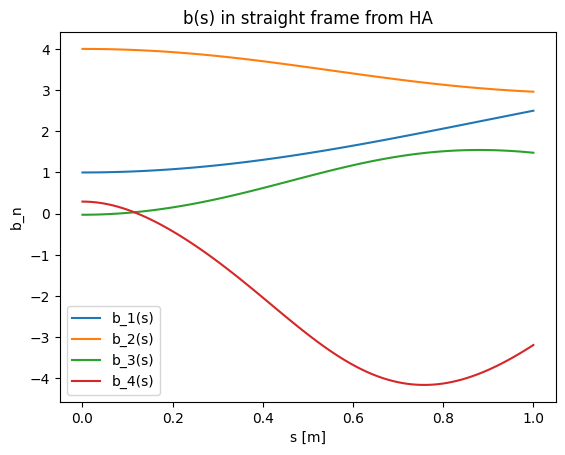

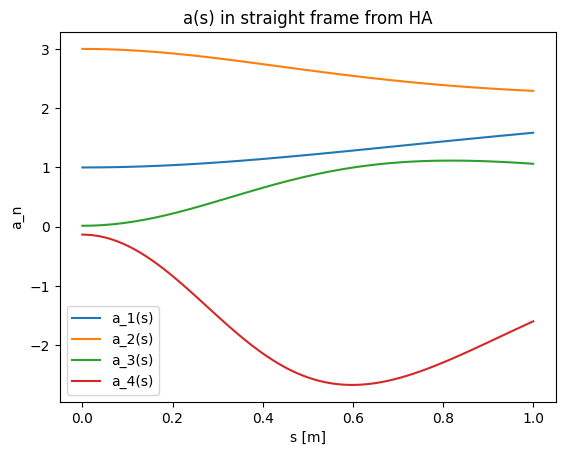

In [88]:
fm_straight_cyl= bpmeth.fieldmaps.Fieldmap(cylfieldmapdatastack)
orderHA=4
svals, astraightofs, bstraightofs, erroras, errorbs = fm_straight_cyl.s_harmonics(rr=rr, ntheta=ntheta, ns=ns, order=orderHA)
for i, b in enumerate(bstraightofs.T):
    plt.plot(svals, b, label=f"b_{i+1}(s)")
plt.xlabel('s [m]')
plt.ylabel('b_n')
plt.title('b(s) in straight frame from HA')
plt.legend()
plt.show()
for i, a in enumerate(astraightofs.T):
    plt.plot(svals, a, label=f"a_{i+1}(s)")
plt.xlabel('s [m]')
plt.ylabel('a_n')
plt.title('a(s) in straight frame from HA')
plt.legend()
plt.show()

As expected an s dependence appeared. To asses the importance of not neglecting it we can see what are the predictions of a naive tracking that would disregard the effect of curvature compared with a more advanced one. 

4
4 4


<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:34: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:34: SyntaxWarning: invalid escape sequence '\D'
/tmp/fmarcoli/ipykernel_40230/3748592863.py:6: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(svals, d, label=f"$\Delta b_{i+1}(s)$")
/tmp/fmarcoli/ipykernel_40230/3748592863.py:15: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(svals, d, label=f"$\Delta$a_{i+1}(s)")
/tmp/fmarcoli/ipykernel_40230/3748592863.py:24: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(svals[20:], d[20:], label=f"$\Delta$b_{i+1}(s)")
/tmp/fmarcoli/ipykernel_40230/3748592863.py:34: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(svals[20:], d[20:], label=f"$\Delta$b_{i+1}(s)")


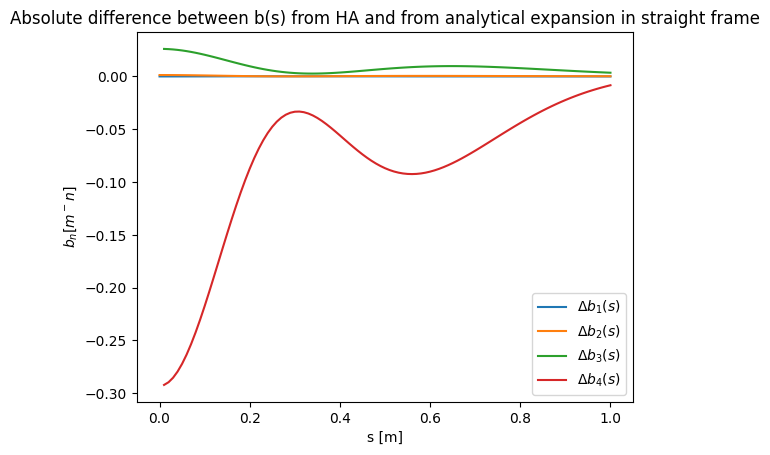

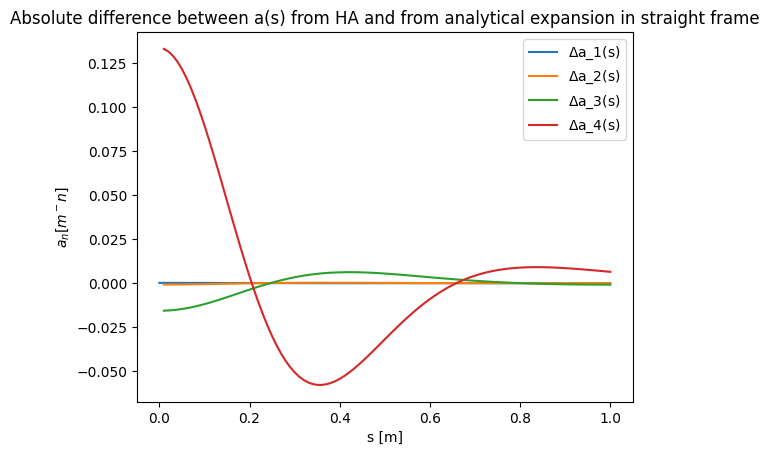

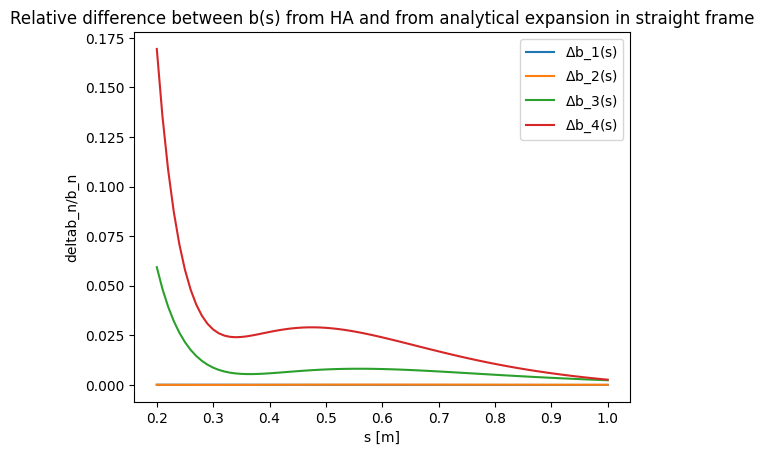

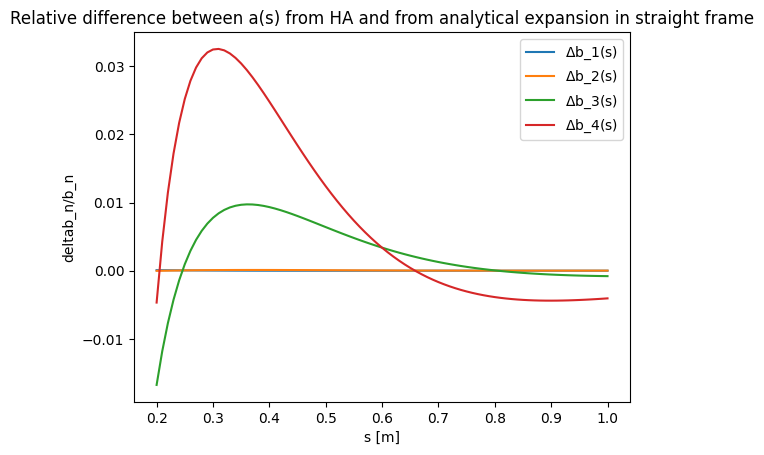

In [90]:
commonsize=min(bstraightofs[0].size,b_vals.T[0].size)
print(commonsize)
print(bstraightofs[0].size, b_vals.T[0].size)
deltab=b_vals[:commonsize,:]-bstraightofs.T[:commonsize,:] 
for i, d in enumerate(deltab[:commonsize]):
    plt.plot(svals, d, label=f"$\Delta b_{i+1}(s)$")
plt.xlabel('s [m]')
plt.ylabel('$b_n [m^-n]$')
plt.title('Absolute difference between b(s) from HA and from analytical expansion in straight frame')
plt.legend()
plt.show()

deltaa=a_vals[:commonsize,:]-astraightofs.T[:commonsize,:] 
for i, d in enumerate(deltaa[:commonsize]):
    plt.plot(svals, d, label=f"$\Delta$a_{i+1}(s)")
plt.xlabel('s [m]')
plt.ylabel('$a_n [m^-n]$')
plt.legend()
plt.title('Absolute difference between a(s) from HA and from analytical expansion in straight frame')
plt.show()

reldeltab=deltab/b_vals[:commonsize]
for i, d in enumerate(reldeltab[:commonsize]):
    plt.plot(svals[20:], d[20:], label=f"$\Delta$b_{i+1}(s)")
    
plt.xlabel('s [m]')
plt.ylabel('deltab_n/b_n')
plt.title('Relative difference between b(s) from HA and from analytical expansion in straight frame')
plt.legend()
plt.show()

reldeltaa=deltaa/a_vals[:commonsize]
for i, d in enumerate(reldeltaa[:commonsize]):
    plt.plot(svals[20:], d[20:], label=f"$\Delta$b_{i+1}(s)")
    
plt.xlabel('s [m]')
plt.ylabel('deltab_n/b_n')
plt.title('Relative difference between a(s) from HA and from analytical expansion in straight frame')
plt.legend()
plt.show()